In [64]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
import tifffile as tiff

In [124]:
path_red_h5 = "/store1/candy/prj_immob/data/cropped/worm2_2_red.h5"
path_green_h5 = "/store1/candy/prj_immob/data/cropped/worm2_2_green.h5"

def print_h5_structure(name, obj):
    """ Recursively prints the HDF5 file structure """
    if isinstance(obj, h5py.Group):
        print(f"Group: {name}")
    elif isinstance(obj, h5py.Dataset):
        print(f"Dataset: {name} | Shape: {obj.shape} | Dtype: {obj.dtype}")
        
with h5py.File(path_red_h5, "r") as f:
    print(f"🔍 Exploring HDF5 File Structure: {path_h5}")
    f.visititems(print_h5_structure)

🔍 Exploring HDF5 File Structure: /store1/candy/prj_immob/data/cropped/worm2_2_red.h5
📂 Group: __DATA_TYPES__
📂 Group: t0
📄 Dataset: t0/channel0 | Shape: (64, 120, 284) | Dtype: uint16
📂 Group: t1
📄 Dataset: t1/channel0 | Shape: (64, 120, 284) | Dtype: uint16
📂 Group: t2
📄 Dataset: t2/channel0 | Shape: (64, 120, 284) | Dtype: uint16
📂 Group: t3
📄 Dataset: t3/channel0 | Shape: (64, 120, 284) | Dtype: uint16
📂 Group: t4
📄 Dataset: t4/channel0 | Shape: (64, 120, 284) | Dtype: uint16


In [175]:
marker_data = []
with h5py.File(path_red_h5, "r") as f:
    groups = list(f.keys())
    for g in groups[1:]:
        marker_data.append(f[g]['channel0'][()])  # Read dataset

activity_data = []
with h5py.File(path_green_h5, "r") as f:
    groups = list(f.keys())
    for g in groups[1:]:
        activity_data = f[g]['channel0'][()]  # Read dataset

In [28]:
# write a new h5py file to be used as the input for segnet
path_out = "/store1/candy/prj_immob/data/hdf5/worm2_2_red.h5"

with h5py.File(path_out, "w") as f:
    f['raw'] = data.astype('uint16')

In [126]:
path_pred = "/store1/candy/prj_immob/data/hdf5/worm2_2_red_predictions.h5"

with h5py.File(path_pred, "r") as f:
    print(f"🔍 Exploring HDF5 File Structure: {path_pred}")
    f.visititems(print_h5_structure)

🔍 Exploring HDF5 File Structure: /store1/candy/prj_immob/data/hdf5/worm2_2_red_predictions.h5
📄 Dataset: predictions | Shape: (2, 64, 120, 284) | Dtype: float32


In [127]:
with h5py.File(path_pred, "r") as f:
    mask = f['predictions'][()]  # Read dataset
    
binary_mask = mask[1] > 0.5
tiff.imwrite("/store1/candy/prj_immob/output/worm2_2_red_binary_mask.tif", binary_mask)

In [128]:
from skimage.measure import label, regionprops

# Step 1: Input - binary_3D is a 3D numpy array with 0/1
binary_3D = binary_mask  # e.g., shape (Z, Y, X)

# Step 2: Connected component labeling in 3D
# connectivity=3 for 26-connectivity in 3D (some libraries differ in how connectivity is parameterized)
labeled_3D = label(binary_3D, connectivity=3)

# Step 3: Extract region properties
regions = regionprops(labeled_3D)

# We can iterate over each region to get properties including coordinates
object_info = []
for region_idx, region in enumerate(regions, start=1):
    # region.label is the label for this region
    # region.coords returns a (N, 3) array of (z, y, x) coordinates for the region
    
    coords = region.coords  # shape: (N_voxels, 3)
    # Optionally convert coords to a list of tuples if needed:
    coords_list = list(map(tuple, coords))

    # Store any properties you need
    info = {
        'object_label': region.label,
        'num_voxels': region.area,
        'centroid': region.centroid, 
        'coords': coords_list
    }
    object_info.append(info)

# Now object_info is a list of dictionaries describing each object
print(f"Found {len(object_info)} connected objects.")
for obj in object_info:
    print(f"Object label: {obj['object_label']}, Voxel count: {obj['num_voxels']}")

Found 178 connected objects.
Object label: 1, Voxel count: 199.0
Object label: 2, Voxel count: 107.0
Object label: 3, Voxel count: 141.0
Object label: 4, Voxel count: 326.0
Object label: 5, Voxel count: 275.0
Object label: 6, Voxel count: 271.0
Object label: 7, Voxel count: 137.0
Object label: 8, Voxel count: 98.0
Object label: 9, Voxel count: 58.0
Object label: 10, Voxel count: 59.0
Object label: 11, Voxel count: 78.0
Object label: 12, Voxel count: 184.0
Object label: 13, Voxel count: 83.0
Object label: 14, Voxel count: 164.0
Object label: 15, Voxel count: 167.0
Object label: 16, Voxel count: 97.0
Object label: 17, Voxel count: 85.0
Object label: 18, Voxel count: 191.0
Object label: 19, Voxel count: 69.0
Object label: 20, Voxel count: 167.0
Object label: 21, Voxel count: 161.0
Object label: 22, Voxel count: 101.0
Object label: 23, Voxel count: 84.0
Object label: 24, Voxel count: 110.0
Object label: 25, Voxel count: 115.0
Object label: 26, Voxel count: 83.0
Object label: 27, Voxel coun

In [130]:
# Filter away ROIs that are very small
min_voxels = 6
filtered_objects = [obj for obj in object_info if obj['num_voxels'] >= min_voxels]

# Create an empty integer array for the filtered labeled volume
filtered_labeled_3D = np.zeros_like(labeled_3D, dtype=np.int32)

# Assign new labels (1..N_filtered) only to the objects we kept
for new_label, obj in enumerate(filtered_objects, start=1):
    filtered_labeled_3D[labeled_3D == obj['object_label']] = new_label

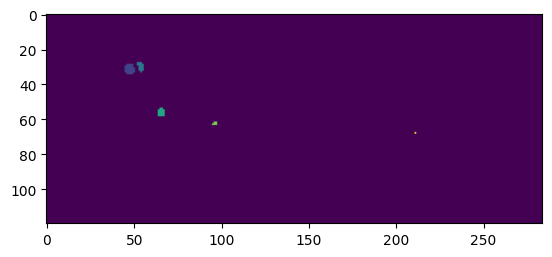

In [131]:
plt.imshow(filtered_labeled_3D[15])

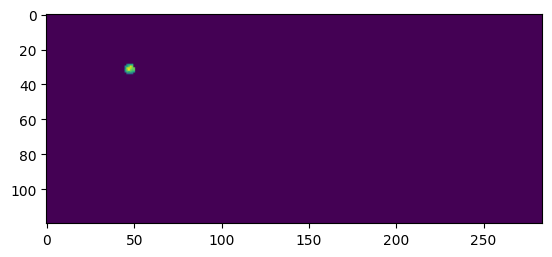

In [134]:
plt.imshow(roi_data[15])

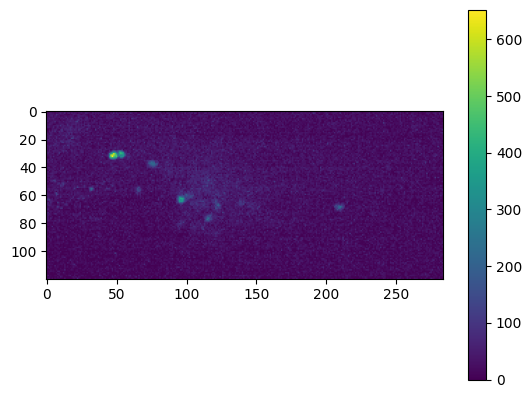

In [162]:
plt.imshow((marker_data - marker_bkg)[15])
plt.colorbar()

In [178]:
marker_data.shape

(5, 64, 120, 284)

In [183]:
dict_roi = dict()
max_t = marker_data.shape[0] # total number of time points

bkg_percentile = 20
marker_bkg = np.percentile(marker_data[0], bkg_percentile)
activity_bkg = np.percentile(activity_data[0], bkg_percentile)
marker_data = np.clip(marker_data - marker_bkg, 0, 4096)
activity_data = np.clip(activity_data - activity_bkg, 0, 4096)

for roi_idx in range(len(filtered_objects)): # each ROI
    roi_num = roi_idx + 1 
    dict_roi[roi_num] = dict()
    roi_mask = (filtered_labeled_3D == roi_num)
    roi_size = np.sum(roi_mask)
    assert roi_size == filtered_objects[roi_idx]['num_voxels']
    dict_roi[roi_num]["roi_size"] = filtered_objects[roi_idx]['num_voxels']
    dict_roi[roi_num]["centroid"] = filtered_objects[roi_idx]['centroid']

    list_marker_value = []
    list_activity_value = []
    list_trace_value = []
    
    for t in range(max_t): # each time point of that ROI
        roi_marker = marker_data[t] * roi_mask
        marker_value = np.sum(roi_marker)
        list_marker_value.append(marker_value)

        roi_activity = activity_data[t] * roi_mask
        activity_value = np.sum(roi_activity)
        list_activity_value.append(activity_value)

        # print(marker_value, activity_value)
        trace_value = activity_value / marker_value # sum of green divided by sum of red pixels
        list_trace_value.append(trace_value)
        
    dict_roi[roi_num]["activity"] = list_activity_value # after background subtraction
    dict_roi[roi_num]["marker"] = list_marker_value # after background subtraction
    dict_roi[roi_num]["trace"] = list_trace_value

In [187]:
dict_roi[150]["trace"]

[0.1990240042205223,
 0.23220602422553327,
 0.21568784125715806,
 0.1969869384524045,
 0.202051118064914]